In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(7)
tf.random.set_seed(7)

In [13]:
"""
Cargar y preparar datos
"""
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
"""
Modelo base sin regularización 
"""
def modelo_base():
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [15]:
"""
Modelo regularizado
"""
def modelo_reg():
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [16]:
"""
Modelo Early stopping
"""
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [17]:
"""
Entrenamiento modelo base y regularizado
"""
base = modelo_base()

hist_base = base.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    verbose=0
)

print("Modelo Base:", base.evaluate(X_test, y_test, verbose=0))

reg = modelo_reg()

hist_reg = reg.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print("Modelo Regularizado:", reg.evaluate(X_test, y_test, verbose=0))

Modelo Base: [0.12336187064647675, 0.9736841917037964]
Modelo Regularizado: [0.08546099811792374, 0.9649122953414917]


Base - Mejor val_loss: 0.1283009946346283
Reg  - Mejor val_loss: 0.14258229732513428
Épocas Reg: 11


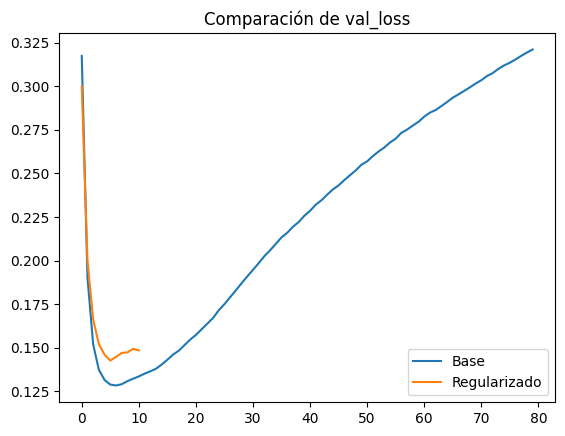

In [19]:
print("Base - Mejor val_loss:", min(hist_base.history["val_loss"]))
print("Reg  - Mejor val_loss:", min(hist_reg.history["val_loss"]))
print("Épocas Reg:", len(hist_reg.history["loss"]))


plt.plot(hist_base.history['val_loss'], label='Base')
plt.plot(hist_reg.history['val_loss'], label='Regularizado')
plt.legend()
plt.title("Comparación de val_loss")
plt.show()

## Análisis y Conclusiones

En esta actividad comparamos dos modelos de red neuronal:

- **Modelo base**: Sin regulación.
- **Modelo regularizado**: Con dropout, l2, y early stopping

Con la evidencia de **Overfitting** se puede observar que:
- El loss de entrenamiento disminuye constantemente
- Pero el loss de validación deja de mejorar o empeora

Esto indica que el modelo memoriza los datos de entrenamiento pero no generaliza bien.

**El modelo regularizado muestra**:

- Mejor comportamiento entre train vs validation
- Menor diferencia entre ambas métricas
- Entrenamiento más corto gracias a Early Stopping

Esto indica que tiene una mejor generalización

**Trade-off Bias vs Variance**

Modelo base:
- Bajo bias (aprende mucho)
- Alta variance (no generaliza bien)

Modelo regularizado:
- Un poco más de bias
- Menor variance

La regularización ayuda a equilibrar este trade-off.

**Como Conclusión**

El uso de técnicas como Dropout, L2 y Early Stopping permite:

- Reducir el overfitting
- Mejorar el rendimiento en datos nuevos
- Obtener un modelo más estable
